# Homework 3

<h1 style="color:green;">
Part 1 - Data Warehouse Modeling: Star Schema
</h1>

<h3 style="color:#8E7CC3;">1.1 Define the Business Process and the Fact Grain</h3>

<b>Business Process</b>
The objective of this data warehouse is to analyze stock market transactions performed during 2024. The analysis focuses on BUY and SELL operations involving publicly traded companies and aims to support transaction analysis across time, industries, sectors, and geographic areas.
<br><br>
<b>Fact Grain</b>
One row in Fact_Transactions represents a single financial transaction recorded in the account statement dataset.


<h3 style="color:#8E7CC3;">1.2 Identify Fact and Dimensions</h3>
The star schema is organized around the Fact_Transactions table, which stores all stock market transactions recorded during 2024.

<b>Fact Table</b>

Fact_Transactions
- IDTransaction
- Date
- Symbol
- TransactionType
- Unit

<br>
<b>Dimension Tables</b>

<b>Dim_Time</b>
- date
- day
- month
- quarter
- year

<b>Dim_Symbol</b>
- symbol
- company_name
- industry
- sector


<b>Dim_Geography</b>
- country
- region
- sub_region

<b>Dim_TransactionType</b>
- transaction_type

<br>
The fact table stores transactional data, while the dimensions provide descriptive information used for analysis. This organization reduces redundancy and supports efficient analytical queries.

<h3 style="color:#8E7CC3;">1.3 Define Dimension Hierarchies </h3>

<b>1. Time Hierarchy (Dim_Time)</b>
This hierarchy supports time-based analysis and aggregation at different levels.

Hierarchy:
Day → Month → Quarter → Year

<br>
<b>2. Geography Hierarchy (Dim_Geography)</b>
This hierarchy allows transactions to be analyzed across different geographic levels.

Hierarchy:
Country → Sub-region → Region

<br>
<b>3. Symbol Hierarchy (Dim_Symbol)</b>
This hierarchy enables the aggregation of transactions from individual stocks to broader business categories.

Hierarchy:
Symbol → Industry → Sector
The company_name attribute is descriptive and belongs to the Symbol level.

<br>
<b>4. Transaction Type Hierarchy (Dim_TransactionType)</b>

Hierarchy: None
This dimension only contains transaction categories such as BUY, SELL, and DIVIDENT.



<h3 style="color:#8E7CC3;">1.4 Design the Star Schema</h3>

The final star schema is composed of a central fact table connected to four dimensions. This structure separates transactional data from descriptive information and supports efficient analytical queries.

<b>Fact Table</b>

Fact_Transactions ( IDTransaction, time_key (FK), symbol_key (FK), geography_key (FK), transaction_type_key (FK), Unit )

<br>
<b>Dimension Tables</b>

Dim_Time ( time_key (PK), date, day, month, quarter, year )

Dim_Symbol ( symbol_key (PK), symbol, company_name, sector, industry )

Dim_Geography ( geography_key (PK), country, region, sub_region )

Dim_TransactionType ( transaction_type_key (PK), transaction_type )


Each dimension uses a  surrogate key generated during the ETL process. These keys provide a stable and efficient way to link the fact table to the dimensions.

The fact table references the dimensions through the foreign keys time_key, symbol_key, geography_key, and transaction_type_key. This allows each transaction to be associated with a specific time period, company, geographic area, and transaction category.

The measure stored in the fact table is Unit, which represents the quantity traded in a transaction and can be aggregated for analytical purposes.

IDTransaction is retained as a descriptive attribute to preserve the connection with the original source data. All remaining descriptive information is stored in the dimension tables.



## Star Schema Diagram

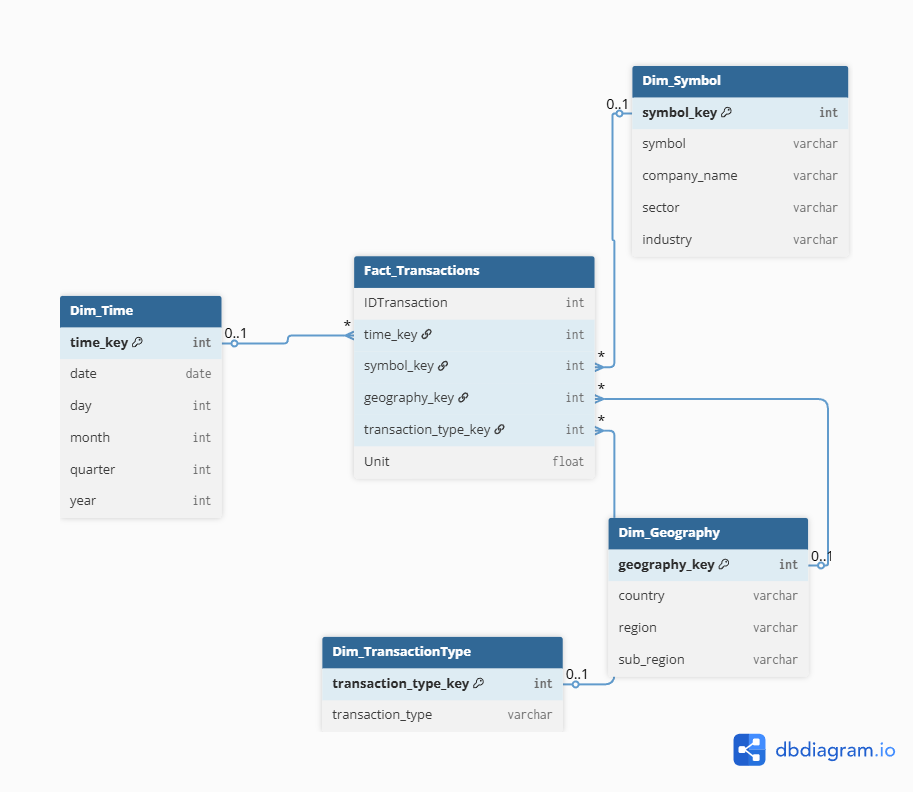

In [29]:
from IPython.display import Image

Image("Star_Schema.png", width=800)

<h1 style="color:green;">
Part 2 Data Transformation and Analysis
</h1>

 <h3 style="color:#8E7CC3;">2.1 Load and Clean the Data</h3>

In [32]:
#Load Datasets
import pandas as pd
import numpy as np


transactions = pd.read_csv(
    "data/account-statement-1-1-2024-12-31-2024.csv",
    sep=";"
)
transactions.head()
symbols = pd.read_csv(
    "data/symbols.csv",
    sep=";"
)
country = pd.read_csv(
    "data/country.csv"
)

print(transactions.columns)
print()
print(symbols.columns)
print()
print(country.columns)

Index(['IDTransaction', 'Date', 'TransactionType', 'Symbol', 'Unit',
       'Unnamed: 5'],
      dtype='str')

Index(['symbol', 'company_name', 'sector', 'industry', 'country'], dtype='str')

Index(['name', 'alpha-2', 'alpha-3', 'country-code', 'iso_3166-2', 'region',
       'sub-region', 'intermediate-region', 'region-code', 'sub-region-code',
       'intermediate-region-code'],
      dtype='str')


In [33]:
transactions["TransactionType"].value_counts(dropna=False)

TransactionType
SELL        1089
BUY         1082
NaN          464
DIVIDENT     110
Name: count, dtype: int64

In [34]:
transactions.shape
transactions[transactions["TransactionType"].isna()].head()

,IDTransaction,Date,TransactionType,Symbol,Unit,Unnamed: 5
2281,NaN,NaN,NaN,NaN,NaN,NaN
2282,NaN,NaN,NaN,NaN,NaN,NaN
2283,NaN,NaN,NaN,NaN,NaN,NaN
2284,NaN,NaN,NaN,NaN,NaN,NaN
2285,NaN,NaN,NaN,NaN,NaN,NaN


In [35]:
# Check missing values
print(transactions.isna().sum())
print()
print(symbols.isna().sum())
print()
print(country.isna().sum())
# I removed rows empty rows 
transactions = transactions.dropna(
    how="all"
)
transactions.shape
print(transactions.isna().sum())

# Remove unused attribute
transactions = transactions.drop(
    columns=["Unnamed: 5"]
)
transactions.head()

IDTransaction       464
Date                464
TransactionType     464
Symbol              464
Unit                464
Unnamed: 5         2745
dtype: int64

symbol          0
company_name    0
sector          0
industry        0
country         0
dtype: int64

name                          0
alpha-2                       1
alpha-3                       0
country-code                  0
iso_3166-2                    0
region                        2
sub-region                    2
intermediate-region         144
region-code                   2
sub-region-code               2
intermediate-region-code    144
dtype: int64
IDTransaction         0
Date                  0
TransactionType       0
Symbol                0
Unit                  0
Unnamed: 5         2281
dtype: int64


,IDTransaction,Date,TransactionType,Symbol,Unit
0,2.769834e+09,11/01/2024 10:44:03,BUY,BAP,1605.0
1,2.767325e+09,24/01/2024 08:07:24,SELL,BAP,1605.0
2,2.815474e+09,10/01/2024 11:00:08,SELL,BAP,914.0
3,2.622244e+09,16/01/2024 08:14:21,BUY,ACGL,646.0
4,2.629871e+09,16/01/2024 14:34:12,SELL,ALVO,646.0


In [36]:
# Verify Transaction Symbols
missing_symbols = set(transactions["Symbol"]) - set(symbols["symbol"])
print("Missing symbols:", len(missing_symbols))
print(missing_symbols)

# Verify Country Mapping
missing_countries = set(symbols["country"]) - set(country["name"])

print("Missing countries:", len(missing_countries))
print(missing_countries)

Missing symbols: 18
{'VWS', 'AZM', 'MONC', 'RIGZU', 'ARCH', 'FNC', 'IBE', 'UCG', 'TKC', 'CCAP', 'OBDC', 'SAP', 'WF', 'AGO.l', 'RCMT', 'MFG', 'CSIQ', 'HTGC'}
Missing countries: 2
{'Taiwan', 'Turkey'}


During the validation process, two country names from the symbols dataset could not be matched directly with the country reference table. Taiwan is listed under a different name in the country dataset, while Turkey is not present among the available country records. These mismatches were identified and documented before proceeding with the creation of the dimensional model.



<h3 style="color:#8E7CC3;"> Create Dimension Tables</h3>

In [37]:
# Convert Date into datetime format

transactions["Date"] = pd.to_datetime(
    transactions["Date"],
    dayfirst=True
)

# Create Dim_Time

dim_time = pd.DataFrame({
    "date": transactions["Date"].dt.date,
    "day": transactions["Date"].dt.day,
    "month": transactions["Date"].dt.month,
    "quarter": transactions["Date"].dt.quarter,
    "year": transactions["Date"].dt.year
}).drop_duplicates()

# Create surrogate key

dim_time = dim_time.reset_index(drop=True)

dim_time.insert(
    0,
    "time_key",
    range(1, len(dim_time) + 1)
)



In [38]:
# Create Dim_Geography

dim_geography = country[
    ["name", "region", "sub-region"]
].copy()

# Rename columns

dim_geography = dim_geography.rename(
    columns={
        "name": "country",
        "sub-region": "sub_region"
    }
)

# Remove duplicate records

dim_geography = dim_geography.drop_duplicates()

# Reset index

dim_geography = dim_geography.reset_index(
    drop=True
)

# Create surrogate key

dim_geography.insert(
    0,
    "geography_key",
    range(1, len(dim_geography) + 1)
)

dim_geography.head()

,geography_key,country,region,sub_region
0,1,Afghanistan,Asia,Southern Asia
1,2,Åland Islands,Europe,Northern Europe
2,3,Albania,Europe,Southern Europe
3,4,Algeria,Africa,Northern Africa
4,5,American Samoa,Oceania,Polynesia


In [39]:
# Create Dim_Symbol

dim_symbol = symbols[
    ["symbol", "company_name", "sector", "industry"]
].copy()

# Remove duplicate records

dim_symbol = dim_symbol.drop_duplicates()

# Reset index

dim_symbol = dim_symbol.reset_index(
    drop=True
)

# Create surrogate key

dim_symbol.insert(
    0,
    "symbol_key",
    range(1, len(dim_symbol) + 1)
)

dim_symbol.head()

,symbol_key,symbol,company_name,sector,industry
0,1,TEAM,Atlassian Corporation,Technology,Software - Application
1,2,WDS,Woodside Energy Group Limited,Energy,Oil & Gas E&P
2,3,OSW,OneSpaWorld Holdings Limited,Consumer Cyclical,Leisure
3,4,ACGL,Arch Capital Group Ltd.,Financial Services,Insurance - Diversified
4,5,AGO,Assured Guaranty Ltd.,Financial Services,Insurance - Specialty


In [40]:
# Create Dim_TransactionType

dim_transaction_type = pd.DataFrame({
    "transaction_type": transactions["TransactionType"].unique()
})

# Sort values

dim_transaction_type = dim_transaction_type.sort_values(
    by="transaction_type"
)

# Reset index

dim_transaction_type = dim_transaction_type.reset_index(
    drop=True
)

# Create surrogate key

dim_transaction_type.insert(
    0,
    "transaction_type_key",
    range(1, len(dim_transaction_type) + 1)
)

dim_transaction_type 


,transaction_type_key,transaction_type
0,1,BUY
1,2,DIVIDENT
2,3,SELL


<h3 style="color:#8E7CC3;"> Create Fact_Transactions</h3>

In [41]:
# Add transaction type key

fact_transactions = transactions.merge(
    dim_transaction_type,
    left_on="TransactionType",
    right_on="transaction_type",
    how="left"
)

# Add symbol key

fact_transactions = fact_transactions.merge(
    dim_symbol[["symbol_key", "symbol"]],
    left_on="Symbol",
    right_on="symbol",
    how="left"
)

# Add time key

fact_transactions["date"] = fact_transactions["Date"].dt.date

fact_transactions = fact_transactions.merge(
    dim_time[["time_key", "date"]],
    on="date",
    how="left"
) 

# Add country information from symbols dataset

fact_transactions = fact_transactions.merge(
    symbols[["symbol", "country"]],
    left_on="Symbol",
    right_on="symbol",
    how="left"
)

# Add geography key

fact_transactions = fact_transactions.merge(
    dim_geography[["geography_key", "country"]],
    on="country",
    how="left"
)

In [42]:
# Create the final Fact_Transactions table

fact_transactions = fact_transactions[
    [
        "IDTransaction",
        "time_key",
        "symbol_key",
        "transaction_type_key",
        "geography_key",
        "Unit"
    ]
]


# After cleaning and preparing the datasets, the dimensional model was built by creating the 
# #four dimension tables together with the Fact_Transactions table. Before transforming the data, 
# #several checks were carried out to identify missing values, remove unnecessary columns, 
# #and verify that symbols and countries matched correctly across the datasets. 
# The final fact table includes only the transaction measure and the foreign keys needed 
# to connect each transaction to the related dimensions, following the structure of the star 
# schema designed for this project.

dim_time.to_csv("dim_time.csv", index=False)
dim_symbol.to_csv("dim_symbol.csv", index=False)
dim_geography.to_csv("dim_geography.csv", index=False)
dim_transaction_type.to_csv(
    "dim_transaction_type.csv",
    index=False
)
fact_transactions.to_csv(
    "fact_transactions.csv",
    index=False
)
fact_transactions = pd.read_csv("fact_transactions.csv")
dim_time = pd.read_csv("dim_time.csv")
dim_symbol = pd.read_csv("dim_symbol.csv")
dim_geography = pd.read_csv("dim_geography.csv")

 <h3 style="color:#8E7CC3;">2.2 Analytical Questions</h3>

In [43]:
# 1. What are the top 5 sectors by number of SELL transactions in US during 2024?

q1 = fact_transactions.merge(
    dim_symbol[["symbol_key", "sector"]],
    on="symbol_key",
    how="left"
)

q1 = q1.merge(
    dim_geography[["geography_key", "country"]],
    on="geography_key",
    how="left"
)

q1 = q1[
    (q1["transaction_type_key"] == 3) &
    (q1["country"] == "United States of America")
]

top5_sectors_sell_us = (
    q1.groupby("sector")
      .size()
      .reset_index(name="sell_transactions")
      .sort_values(
          by="sell_transactions",
          ascending=False
      )
      .head(5)
)

top5_sectors_sell_us

,sector,sell_transactions
6,Technology,158
0,Communication Services,58
3,Financial Services,55
4,Healthcare,50
1,Consumer Cyclical,48


In 2024, the Technology sector accounted for the largest number of SELL transactions in the United States, totaling 158 transactions. The next most active sectors were Communication Services, Financial Services, Healthcare, and Consumer Cyclical. These findings indicate that sell activity was heavily concentrated in technology-related companies, which recorded substantially more transactions than the other sectors considered.

In [44]:
# 2. What are the top 5 industries by number of BUY transactions in Q4 of 2024?

q2 = fact_transactions.merge(
    dim_time[["time_key", "quarter"]],
    on="time_key",
    how="left"
)

q2 = q2.merge(
    dim_symbol[["symbol_key", "industry"]],
    on="symbol_key",
    how="left"
)

q2 = q2[
    (q2["transaction_type_key"] == 1) &
    (q2["quarter"] == 4)
]

top5_industries_buy_q4 = (
    q2.groupby("industry")
      .size()
      .reset_index(name="buy_transactions")
      .sort_values(
          by="buy_transactions",
          ascending=False
      )
      .head(5)
)

top5_industries_buy_q4

,industry,buy_transactions
17,Semiconductors,18
10,Internet Content & Information,15
19,Software - Infrastructure,10
11,Internet Retail,8
4,Diagnostics & Research,7


The analysis shows that the Semiconductors industry generated the highest number of BUY transactions in the last quarter of 2024, with a total of 18 operations. Internet Content & Information followed with 15 transactions, while Software - Infrastructure ranked third. Internet Retail and Diagnostics & Research also appeared among the most traded industries. These results highlight a strong concentration of buying activity in technology-oriented sectors during Q4 2024.


In [45]:
# 3. Rank all quarters of 2024 by total number of transactions (BUY + SELL).

q3 = fact_transactions.merge(
    dim_time[["time_key", "quarter"]],
    on="time_key",
    how="left"
)

q3 = q3[
    q3["transaction_type_key"].isin([1, 3])
]

quarter_ranking = (
    q3.groupby("quarter")
      .size()
      .reset_index(name="total_transactions")
      .sort_values(
          by="total_transactions",
          ascending=False
      )
)

quarter_ranking

,quarter,total_transactions
0,1,1076
1,2,580
2,3,260
3,4,255


The first quarter of 2024 recorded the highest trading activity, with 1,076 BUY and SELL transactions. Transaction volumes then decreased considerably in the second quarter, which registered 580 operations. The third and fourth quarters showed very similar levels of activity, with 260 and 255 transactions respectively. Overall, the results indicate that most trading activity was concentrated during the first half of the year, particularly in Q1.


In [46]:
# 4. What are the top 10 countries by number of SELL transactions in 2024?

q4 = fact_transactions.merge(
    dim_geography[["geography_key", "country"]],
    on="geography_key",
    how="left"
)

q4 = q4[
    q4["transaction_type_key"] == 3
]

top10_countries_sell = (
    q4.groupby("country")
      .size()
      .reset_index(name="sell_transactions")
      .sort_values(
          by="sell_transactions",
          ascending=False
      )
      .head(10)
)

top10_countries_sell

,country,sell_transactions
18,United States of America,389
17,United Kingdom of Great Britain and Northern I...,130
4,China,112
1,Brazil,69
13,"Netherlands, Kingdom of the",46
16,Switzerland,37
8,Ireland,31
10,Luxembourg,27
2,Canada,22
5,Germany,18


The United States of America recorded the highest number of SELL transactions in 2024, with a total of 389 transactions. The United Kingdom ranked second with 130 transactions, followed by China with 112. Brazil and Taiwan also showed significant selling activity, while the Netherlands, Switzerland, Ireland, Luxembourg, and Canada completed the top ten. The results indicate that SELL transactions were heavily concentrated in companies based in the United States and other major international financial markets.


In [47]:
# 5.  What are the top 5 regions by total units bought in 2024?

q5 = fact_transactions.merge(
    dim_geography[["geography_key", "region"]],
    on="geography_key",
    how="left"
)

q5 = q5[
    q5["transaction_type_key"] == 1
]

top5_regions_buy_units = (
    q5.groupby("region")["Unit"]
      .sum()
      .reset_index(name="total_units_bought")
      .sort_values(
          by="total_units_bought",
          ascending=False
      )
      .head(5)
)

top5_regions_buy_units

,region,total_units_bought
0,Americas,37026.0
2,Europe,22528.0
1,Asia,9198.0


The Americas recorded the highest volume of units purchased during 2024, with a total of 37,026 units. Europe ranked second with 22,528 units, while Asia accounted for 9,198 units. No other regions were represented in the dataset for BUY transactions. The results show that purchasing activity was primarily concentrated in the Americas, which significantly outperformed the other geographic regions in terms of trading volume.
